In [1]:
import pandas as pd
import ast
import os

def extract_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
os.chdir('/active-data/genomes/bacteria_complete_annotationRefSeq-20250807')
sub_data = pd.read_csv("assembly_submission_info.tsv", sep='\t')
sub_data['submissionDate'] = pd.to_datetime(sub_data['submissionDate'])
sub_data['year'] = sub_data['submissionDate'].dt.year

In [3]:
all_result = []
for genus_name in keep_genus:
    os.chdir(f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}')
    contig_info = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
    all_result.append(contig_info)
all_result = pd.concat(all_result, ignore_index=True)
all_result['gcf_id'] = all_result['accession'].str.split('-').str[0]

In [4]:
all_gcf = set(all_result['gcf_id'])
print(len(all_gcf))

gcf_trp = set(all_result[all_result['category-pident_90']=='intermediate replicon']['gcf_id'])
print(len(gcf_trp))

28581
706


In [5]:
all_acc_perc = []
trans_acc_perc = []

acc_bio = pd.read_csv('/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/biosample_info.tsv', sep='\t')
acc_time = pd.read_csv('/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/assembly_submission_info.tsv', sep='\t')
acc_time["submissionDate"] = pd.to_datetime(acc_time["submissionDate"])

for genus_name in keep_genus:    
    target_dir = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    replicon_data = pd.read_csv(f'{target_dir}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
    replicon_data['acc_n'] = replicon_data['accession'].str.split('-').str[0]
    all_acc = set(replicon_data['acc_n'])
    
    all_trans = replicon_data[replicon_data['category-pident_90']=='intermediate replicon']
    trans_acc = set(all_trans['acc_n'])
    
    all_bio = acc_time[acc_time['accession'].isin(all_acc)]
    trans_bio = acc_time[acc_time['accession'].isin(trans_acc)]
    
    target_methods = ['PacBio', 'Illumina', 'Oxford Nanopore']
    for bio_info, cate in zip([all_bio, trans_bio], [all_acc_perc, trans_acc_perc]):
        try:
            data = {}
            for method in target_methods:
                data[method] = len(bio_info[bio_info['sequencingTech'].str.contains(method, case=False, na=False)])
            res = {k: data.get(k, 0)/len(bio_info)*100 for k in target_methods}
            res['genus'] = genus_name
            cate.append(pd.DataFrame([res]))
        except:
            pass

all_acc_perc = pd.concat(all_acc_perc, ignore_index=True)
trans_acc_perc = pd.concat(trans_acc_perc, ignore_index=True)

In [6]:
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

def create_broken_axes(ax, split_ratio=0.7, hspace=0.05):
    fig = ax.figure
    bbox = ax.get_position()

    total_height = bbox.height
    usable_height = total_height - hspace
    top_h = usable_height * split_ratio
    bottom_h = usable_height * (1 - split_ratio)

    ax1 = fig.add_axes([bbox.x0, bbox.y0 + bottom_h + hspace, bbox.width, top_h])
    ax2 = fig.add_axes([bbox.x0, bbox.y0, bbox.width, bottom_h])

    return ax1, ax2

def plot_year_bar(ax1, ax2, year_counts: dict, colors: dict, ylim_top=(200, 1000), ylim_bottom=(0, 50), d=0.015):
    h1 = ax1.get_position().height
    h2 = ax2.get_position().height
    split_ratio = h1 / (h1 + h2)

    all_years = []
    for s in year_counts.values():
        all_years.extend(s.index.tolist())
    min_year = min(all_years)
    max_year = max(all_years)
    years = np.arange(min_year, max_year + 1)
    n_groups = len(year_counts)
    width = 0.9
    labels = list(year_counts.keys())

    for ax in [ax1, ax2]:
        for i, label in enumerate(labels):
            data = year_counts[label].reindex(years, fill_value=0)
            ax.bar(
                years,
                data, width=width,
                label=label, color=colors[label]
            )

    ax1.set_ylim(*ylim_top)
    ax2.set_ylim(*ylim_bottom)
    ax1.set_xlim(min_year-1, max_year+1)
    ax2.set_xlim(min_year-1, max_year+1)

    kwargs = dict(color='black', linewidth=1.5, clip_on=False)
    min_ratio = min(split_ratio, 1 - split_ratio)
    dy1 = 2 * d / split_ratio * min_ratio
    dy2 = 2 * d / (1 - split_ratio) * min_ratio

    ax1.plot((1-d, 1+d), (0-dy1, 0+dy1), transform=ax1.transAxes, **kwargs)
    ax1.plot((-d, d),   (0-dy1, 0+dy1), transform=ax1.transAxes, **kwargs)
    ax2.plot((1-d, 1+d), (1-dy2, 1+dy2), transform=ax2.transAxes, **kwargs)
    ax2.plot((-d, d),   (1-dy2, 1+dy2), transform=ax2.transAxes, **kwargs)

    ax2.spines['top'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax2.set_xticks(years)
    ax2.tick_params(axis='x', rotation=30)
    plt.setp(ax2.get_xticklabels(), ha='right', va='top', rotation_mode='anchor')
    ax2.set_xlabel('Submission year')
    ax1.set_xticks([])
    ax1.legend(loc='upper left')

def plot_violin_jitter_two_groups(ax, df_all, df_trans):
    tech_cols = ["PacBio", "Illumina", "Oxford Nanopore"]
    n_tech = len(tech_cols)
    base_x = np.arange(n_tech)
    offset = 0.18
    pos_all = base_x - offset
    pos_trans = base_x + offset

    df_all10 = df_all.head(10).copy()
    df_tr10 = df_trans.head(10).copy()

    all_genus = pd.concat([df_all10["genus"], df_tr10["genus"]]).unique()
    cmap = plt.cm.tab10
    genus_color = {g: cmap(i) for i, g in enumerate(all_genus)}

    sig_dict = {}
    sig_y_offset = 3
    for i, col in enumerate(tech_cols):
        dataA = df_all10[col].dropna()
        dataB = df_tr10[col].dropna()
        stat, pval = ttest_ind(dataA, dataB, equal_var=False)
        sig_dict[col] = pval

        if pval < 0.001:
            mark = "***"
        elif pval < 0.01:
            mark = "**"
        elif pval < 0.05:
            mark = "*"
        else:
            mark = "ns"

        maxA = dataA.max()
        maxB = dataB.max()
        y_h = max(maxA, maxB) + sig_y_offset
        mid_x = base_x[i]

        ax.plot([mid_x-offset, mid_x+offset], [y_h, y_h], c="black", lw=0.8)
        ax.text(mid_x, y_h + 0.01, mark, ha="center", va="bottom")

    data_all = [df_all10[col].values for col in tech_cols]
    vp1 = ax.violinplot(data_all, positions=pos_all, widths=0.28, showmedians=True)
    for pc in vp1["bodies"]:
        pc.set_facecolor("#888888")
        pc.set_alpha(0.55)
    data_tr = [df_tr10[col].values for col in tech_cols]
    vp2 = ax.violinplot(data_tr, positions=pos_trans, widths=0.28, showmedians=True)
    for pc in vp2["bodies"]:
        pc.set_facecolor("#222222")
        pc.set_alpha(0.45)

    jitter_strength = 0.06
    for _, row in df_all10.iterrows():
        g = row["genus"]
        c = genus_color[g]
        for i, col in enumerate(tech_cols):
            x_jit = pos_all[i] + np.random.uniform(-jitter_strength, jitter_strength)
            ax.scatter(x_jit, row[col], color=c, s=28, alpha=0.75, edgecolor="white", lw=0)
    for _, row in df_tr10.iterrows():
        g = row["genus"]
        c = genus_color[g]
        for i, col in enumerate(tech_cols):
            x_jit = pos_trans[i] + np.random.uniform(-jitter_strength, jitter_strength)
            ax.scatter(x_jit, row[col], color=c, s=28, alpha=0.75, edgecolor="white", lw=0)

    ax.set_xticks(base_x)
    ax.set_xticklabels(tech_cols)
    ax.set_xlabel("Sequencing methods")
    ax.set_ylabel("Accession percentage (%)")
    ax.grid(axis="y", ls="--", alpha=0.3)
    ax.set_xlim(-0.5, n_tech - 0.5)

    patch_all = mpatches.Patch(color="#888888", alpha=0.55, label="All accessions", lw=0)
    patch_tr = mpatches.Patch(color="#222222", alpha=0.45, label="IR-containing accessions", lw=0)
    leg1 = ax.legend(handles=[patch_all, patch_tr], loc="best")
    ax.add_artist(leg1)

    return genus_color, sig_dict

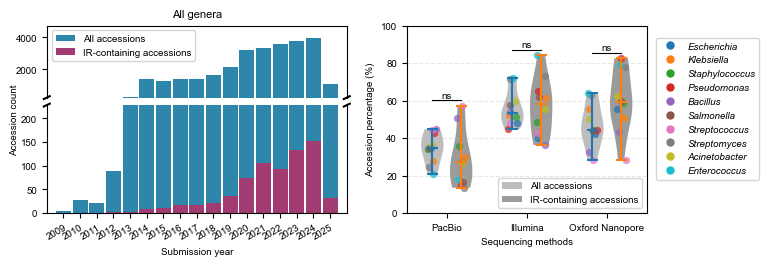

In [7]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
import numpy as np

np.random.seed(42)

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})
italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

year_count1 = sub_data[sub_data['accession'].isin(all_gcf)]['year'].value_counts().sort_index()
year_count2 = sub_data[sub_data['accession'].isin(gcf_trp)]['year'].value_counts().sort_index()

year_counts_dict = {
    'All accessions': year_count1,
    'IR-containing accessions': year_count2
}

colors_dict = {
    'All accessions': '#2E86AB',
    'IR-containing accessions': '#A23B72'
}

fig = plt.figure(figsize=(7.5, 7.5))
main_ax = fig.add_axes([0.05, 0.1, 0.4, 0.25])

ax1, ax2 = create_broken_axes(main_ax, split_ratio=0.4, hspace=0.01)

plot_year_bar(ax1=ax1, ax2=ax2, year_counts=year_counts_dict, colors=colors_dict,
    ylim_top=(year_count2.max()*1.5, max(year_count1.max(), year_count2.max())*1.2),
    ylim_bottom=(0, year_count2.max()*1.5),
    d=0.01
)

main_ax.set_ylabel('Accession count', labelpad=20)
main_ax.set_title('All genera')

main_ax.set_xticks([])
main_ax.set_yticks([])
for spine in main_ax.spines.values():
    spine.set_visible(False)

ax_seq = fig.add_axes([0.53, 0.1, 0.32, 0.25])

genus_color_dict, pvalue_result = plot_violin_jitter_two_groups(ax_seq, all_acc_perc, trans_acc_perc)
genus_handles = [
    Line2D([], [], marker='o', markersize=5, linestyle='', color=genus_color_dict[g], label=g) 
    for g in genus_color_dict.keys()
]
ax_seq.legend(handles=genus_handles, bbox_to_anchor=(1.02, 0.96), loc="upper left", prop=legend_font,)
ax_seq.set_ylim(0, 100)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_accession_submission_date&sequencing_method.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_accession_submission_date&sequencing_method.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()